## VIDEO XMM-LSS Monster coverage

This notebook retrieves the `the_monster_20250219` HTM7 reference-catalogue shards needed to cover the full VIDEO XMM-LSS field.

The workflow follows the ELAIS-S1 Monster-coverage notebook, with two deliberate improvements for transfer and later calibration work:

- HTM7 IDs are selected geometrically from a conservative circular region enclosing the adopted VIDEO field footprint;
- the original Butler artifacts are retrieved with `retrieveArtifacts`, so the archive products are preserved without catalogue rewriting;
- a second, flat directory of `refcat_htm7_<id>.fits` working copies is created with `SimpleCatalog.writeFits` for convenient use by the local Monster–VIDEO calibration notebooks;
- a manifest and coverage plot are written for transfer verification.

The rectangular coordinates below are **conservative bounding limits**, not an exact VIDEO survey mask. They are intentionally slightly larger than the useful field so that no edge HTM7 shard is missed.

### Imports

In [1]:
from pathlib import Path
import shutil
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io.fits.card import VerifyWarning
from astropy.table import Table

import lsst.geom as geom
from lsst.daf.butler import Butler
from lsst.meas.algorithms.htmIndexer import HtmIndexer

warnings.simplefilter(
    "ignore",
    VerifyWarning,
)

### Open the DP2 Butler and verify the Monster dataset

The notebook uses the DP2 chained collection on the Rubin Science Platform and requires exactly `the_monster_20250219`, matching the ELAIS-S1 reference catalogue already used for the VIDEO calibration work.

In [2]:
butler = Butler(
    "dp2",
    collections=[
        "dp2",
    ],
)

monster_name = (
    "the_monster_20250219"
)

monster_dataset_types = sorted(
    dt.name
    for dt
    in butler.registry.queryDatasetTypes(
        "*monster*"
    )
    if dt.name.startswith(
        "the_monster"
    )
)

print(
    "Monster dataset types available:"
)

for name in monster_dataset_types:
    print(
        "  ",
        name,
    )

if monster_name not in monster_dataset_types:
    raise RuntimeError(
        f"{monster_name} was not found "
        "in the DP2 Butler."
    )

print(
    f"\nUsing: {monster_name}"
)

Monster dataset types available:
   the_monster_20250219

Using: the_monster_20250219


### Define the VIDEO XMM-LSS footprint

The adopted rectangular limits are used only to determine a conservative HTM7 selection region:

- RA = 34.00--37.30 deg
- Dec = -5.60---3.70 deg

The circle used by `HtmIndexer.getShardIds` is centred at RA = 35.650 deg, Dec = -4.650 deg. Its radius is calculated from the farthest rectangular corner plus a 0.05-degree safety margin.

This intentionally downloads complete HTM7 shards around the VIDEO footprint rather than clipping the reference catalogue to the exact survey boundary.

In [3]:
VIDEO_RA_MIN = 34.00000000
VIDEO_RA_MAX = 37.30000000
VIDEO_DEC_MIN = -5.60000000
VIDEO_DEC_MAX = -3.70000000

RA_CENTER_DEG = 35.65000000
DEC_CENTER_DEG = -4.65000000

MARGIN_DEG = 0.05

center_coord = SkyCoord(
    RA_CENTER_DEG
    * u.deg,
    DEC_CENTER_DEG
    * u.deg,
    frame="icrs",
)

corner_coords = SkyCoord(
    [
        VIDEO_RA_MIN,
        VIDEO_RA_MIN,
        VIDEO_RA_MAX,
        VIDEO_RA_MAX,
    ]
    * u.deg,
    [
        VIDEO_DEC_MIN,
        VIDEO_DEC_MAX,
        VIDEO_DEC_MIN,
        VIDEO_DEC_MAX,
    ]
    * u.deg,
    frame="icrs",
)

corner_separations = (
    center_coord
    .separation(
        corner_coords
    )
    .deg
)

RADIUS_DEG = float(
    np.max(
        corner_separations
    )
    + MARGIN_DEG
)

print(
    "Angular distances to footprint "
    "corners [deg]:"
)
print(
    np.round(
        corner_separations,
        4,
    )
)
print(
    "Maximum corner distance: "
    f"{np.max(corner_separations):.4f} deg"
)
print(
    "HTM selection radius:    "
    f"{RADIUS_DEG:.4f} deg"
)

Angular distances to footprint corners [deg]:
[1.8982 1.9001 1.8982 1.9001]
Maximum corner distance: 1.9001 deg
HTM selection radius:    1.9501 deg


### Find all HTM7 shards intersecting the selection circle

Monster is partitioned with the Hierarchical Triangular Mesh at depth 7. `HtmIndexer` returns every complete HTM7 shard intersecting the conservative field-selection circle.

In [4]:
htm = HtmIndexer(
    depth=7
)

center = geom.SpherePoint(
    RA_CENTER_DEG
    * geom.degrees,
    DEC_CENTER_DEG
    * geom.degrees,
)

shards, on_boundary = (
    htm.getShardIds(
        center,
        RADIUS_DEG
        * geom.degrees,
    )
)

htm7_ids = sorted(
    {
        int(
            shard
        )
        for shard
        in shards
    }
)

if not htm7_ids:
    raise RuntimeError(
        "No HTM7 shards were found."
    )

print(
    f"Number of HTM7 shards: "
    f"{len(htm7_ids)}"
)
print(
    htm7_ids
)

Number of HTM7 shards: 62
[133200, 133201, 133202, 133203, 133204, 133205, 133206, 133207, 133208, 133209, 133210, 133211, 133212, 133213, 133214, 133215, 133232, 133234, 133235, 133240, 133241, 133243, 133245, 133280, 133282, 133283, 133289, 133293, 133312, 133313, 133314, 133315, 133317, 133318, 133319, 133320, 133321, 133322, 133323, 133324, 133325, 133326, 133327, 133364, 133365, 133367, 133370, 133372, 133968, 134048, 134049, 134050, 134051, 134052, 134053, 134054, 134055, 134060, 134061, 134062, 134063, 134080]


### Resolve the selected HTM7 shards in the DP2 Butler

Each geometric HTM7 ID is resolved to its actual Butler dataset reference before any file is copied. This also provides the dataset IDs recorded in the manifest.

In [5]:
monster_refs = []

missing_htm7 = []

for htm7_id in htm7_ids:

    refs = list(
        butler.registry.queryDatasets(
            monster_name,
            htm7=htm7_id,
        )
    )

    if len(
        refs
    ) == 0:
        missing_htm7.append(
            htm7_id
        )
        continue

    if len(
        refs
    ) > 1:
        print(
            f"Warning: HTM7 {htm7_id} "
            f"resolved to {len(refs)} refs; "
            "using the first ref visible "
            "through the DP2 chain."
        )

    monster_refs.append(
        refs[
            0
        ]
    )

if missing_htm7:
    raise RuntimeError(
        "The following selected HTM7 "
        "shards were not found in DP2: "
        + ", ".join(
            str(
                value
            )
            for value
            in missing_htm7
        )
    )

resolved_htm7 = sorted(
    {
        int(
            ref.dataId[
                "htm7"
            ]
        )
        for ref
        in monster_refs
    }
)

if resolved_htm7 != htm7_ids:
    raise RuntimeError(
        "Resolved HTM7 IDs do not match "
        "the geometric selection."
    )

print(
    f"Successfully resolved "
    f"{len(monster_refs)} Monster datasets."
)

for ref in sorted(
    monster_refs,
    key=lambda item: item.dataId[
        "htm7"
    ],
):
    print(
        f"htm7={ref.dataId['htm7']}  "
        f"dataset_id={ref.id}"
    )

Successfully resolved 62 Monster datasets.
htm7=133200  dataset_id=a7ac26f7-9957-47a1-849a-870161e2dc97
htm7=133201  dataset_id=70664222-07f5-45b8-bd26-5bca4fdf6abb
htm7=133202  dataset_id=9c084aa8-3938-409b-a8b3-c7a701a604c1
htm7=133203  dataset_id=84a92468-8e91-46cb-b46b-bfc464386069
htm7=133204  dataset_id=9904d29f-1d84-4c73-9b16-5c132aa24bd0
htm7=133205  dataset_id=36781b07-7870-421e-a0a2-747bd4c25b5a
htm7=133206  dataset_id=1427398b-6bf1-48f8-b26a-bd4977b7ca42
htm7=133207  dataset_id=6ec221c7-0b66-4d46-9342-d490f34a67c6
htm7=133208  dataset_id=034413ad-a92c-4f30-b025-a873041048b3
htm7=133209  dataset_id=fc6c7244-f490-4c46-b3ec-e6dfce60283a
htm7=133210  dataset_id=5597095a-4eb0-4df7-b5c2-feae43f5af5d
htm7=133211  dataset_id=9b32f0d0-9e05-4ecd-843d-3d40ab98d582
htm7=133212  dataset_id=040af475-3fc4-46d7-a173-5765ffbeaf61
htm7=133213  dataset_id=2504ea63-3f4a-4015-aa80-598f55da223b
htm7=133214  dataset_id=b70e6e1e-4803-47ed-a4ae-084447c1a3df
htm7=133215  dataset_id=2298e121-9351-4e67

### Create the RSP working directory and write the HTM7 manifest

The manifest is written before retrieval so the exact required shard list can be compared with any Monster files already present on CSD3.

In [6]:
work_dir = Path(
    "data/the_monster_20250219/XMM"
)

work_dir.mkdir(
    parents=True,
    exist_ok=True,
)

manifest_path = (
    work_dir
    / "XMM_htm7_manifest.txt"
)

with manifest_path.open(
    "w"
) as stream:

    stream.write(
        f"dataset_type: {monster_name}\n"
    )
    stream.write(
        f"field: XMM-LSS\n"
    )
    stream.write(
        f"ra_min_deg: {VIDEO_RA_MIN}\n"
    )
    stream.write(
        f"ra_max_deg: {VIDEO_RA_MAX}\n"
    )
    stream.write(
        f"dec_min_deg: {VIDEO_DEC_MIN}\n"
    )
    stream.write(
        f"dec_max_deg: {VIDEO_DEC_MAX}\n"
    )
    stream.write(
        f"ra_center_deg: {RA_CENTER_DEG}\n"
    )
    stream.write(
        f"dec_center_deg: {DEC_CENTER_DEG}\n"
    )
    stream.write(
        f"selection_radius_deg: "
        f"{RADIUS_DEG:.6f}\n"
    )
    stream.write(
        f"n_htm7: {len(htm7_ids)}\n\n"
    )
    stream.write(
        "htm7\tdataset_id\n"
    )

    for ref in sorted(
        monster_refs,
        key=lambda item: item.dataId[
            "htm7"
        ],
    ):
        stream.write(
            f"{ref.dataId['htm7']}"
            f"\t{ref.id}\n"
        )

print(
    f"Manifest: {manifest_path}"
)

Manifest: data/the_monster_20250219/XMM/XMM_htm7_manifest.txt


### Retrieve the original Butler artifacts

`retrieveArtifacts` copies the original datastore artifacts to the RSP filesystem. These are the authoritative files to preserve for transfer and provenance.

In [7]:
artifact_dir = (
    work_dir
    / "original_artifacts"
)

artifact_dir.mkdir(
    parents=True,
    exist_ok=True,
)

downloaded = (
    butler.retrieveArtifacts(
        monster_refs,
        destination=str(
            artifact_dir
        ),
        transfer="copy",
        preserve_path=True,
        overwrite=True,
    )
)

print(
    f"Downloaded {len(downloaded)} "
    "original artifacts."
)
print(
    f"Destination: {artifact_dir}"
)

if len(
    downloaded
) != len(
    monster_refs
):
    raise RuntimeError(
        "The number of downloaded artifacts "
        "does not match the number of "
        "resolved Monster refs."
    )

Downloaded 62 original artifacts.
Destination: data/the_monster_20250219/XMM/original_artifacts


### Create flat `refcat_htm7_<id>.fits` working copies

The original artifacts above remain untouched. For the local Monster–VIDEO calibration notebooks it is convenient to have one flat directory with predictable filenames.

Each dataset is read directly from Butler and written with the catalogue's own `writeFits` method. No schema mapping, column conversion, or catalogue augmentation is performed.

In [8]:
flat_dir = work_dir

flat_summary = []

for ref in sorted(
    monster_refs,
    key=lambda item: item.dataId[
        "htm7"
    ],
):

    htm7_id = int(
        ref.dataId[
            "htm7"
        ]
    )

    cat = butler.get(
        ref
    )

    filename = (
        flat_dir
        / f"refcat_htm7_{htm7_id}.fits"
    )

    cat.writeFits(
        str(
            filename
        )
    )

    flat_summary.append(
        (
            htm7_id,
            len(
                cat
            ),
            filename,
        )
    )

    print(
        f"Saved {filename.name}: "
        f"{len(cat):,} rows"
    )

if len(
    flat_summary
) != len(
    htm7_ids
):
    raise RuntimeError(
        "Flat-shard count mismatch."
    )

Saved refcat_htm7_133200.fits: 761 rows
Saved refcat_htm7_133201.fits: 782 rows
Saved refcat_htm7_133202.fits: 746 rows
Saved refcat_htm7_133203.fits: 772 rows
Saved refcat_htm7_133204.fits: 771 rows
Saved refcat_htm7_133205.fits: 832 rows
Saved refcat_htm7_133206.fits: 726 rows
Saved refcat_htm7_133207.fits: 809 rows
Saved refcat_htm7_133208.fits: 821 rows
Saved refcat_htm7_133209.fits: 770 rows
Saved refcat_htm7_133210.fits: 791 rows
Saved refcat_htm7_133211.fits: 777 rows
Saved refcat_htm7_133212.fits: 779 rows
Saved refcat_htm7_133213.fits: 814 rows
Saved refcat_htm7_133214.fits: 786 rows
Saved refcat_htm7_133215.fits: 788 rows
Saved refcat_htm7_133232.fits: 790 rows
Saved refcat_htm7_133234.fits: 790 rows
Saved refcat_htm7_133235.fits: 790 rows
Saved refcat_htm7_133240.fits: 731 rows
Saved refcat_htm7_133241.fits: 754 rows
Saved refcat_htm7_133243.fits: 778 rows
Saved refcat_htm7_133245.fits: 765 rows
Saved refcat_htm7_133280.fits: 785 rows
Saved refcat_htm7_133282.fits: 697 rows


### Verify the flat working copies

The expected and written HTM7 IDs must match exactly.

In [9]:
flat_files = sorted(
    flat_dir.glob(
        "refcat_htm7_*.fits"
    )
)

flat_ids = sorted(
    int(
        path.stem.split(
            "_"
        )[
            -1
        ]
    )
    for path
    in flat_files
)

missing_flat = sorted(
    set(
        htm7_ids
    )
    - set(
        flat_ids
    )
)

extra_flat = sorted(
    set(
        flat_ids
    )
    - set(
        htm7_ids
    )
)

print(
    f"Expected HTM7 shards: "
    f"{len(htm7_ids)}"
)
print(
    f"Flat FITS shards:     "
    f"{len(flat_ids)}"
)
print(
    "Missing:",
    missing_flat,
)
print(
    "Unexpected:",
    extra_flat,
)

if (
    missing_flat
    or extra_flat
):
    raise RuntimeError(
        "Flat-shard verification failed."
    )

Expected HTM7 shards: 62
Flat FITS shards:     62
Missing: []
Unexpected: []


### Plot the downloaded Monster coverage

The plot shows the complete HTM7 working copies, the adopted VIDEO bounding rectangle, and the circular HTM selection region. Right ascension increases to the left following the usual astronomical convention.

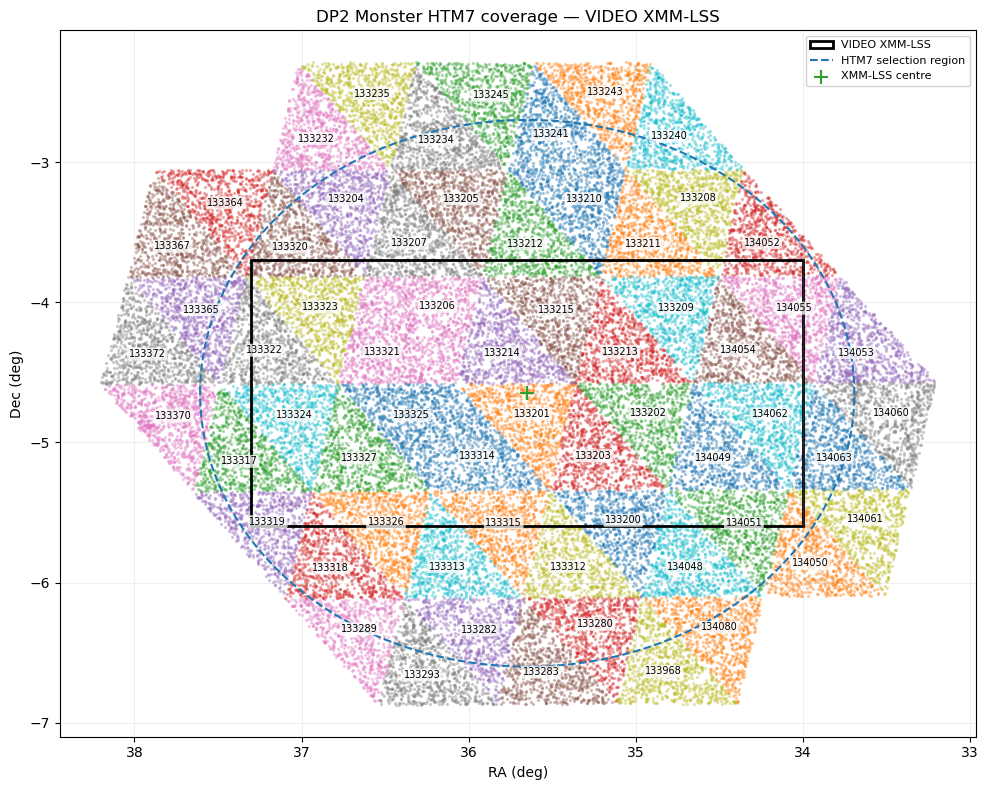

Saved: data/the_monster_20250219/XMM/VIDEO_XMM_Monster_coverage.png


In [10]:
fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)

for fits_file in flat_files:

    cat = Table.read(
        fits_file
    )

    ra_values = np.asarray(
        cat[
            "coord_ra"
        ],
        dtype=float,
    )

    dec_values = np.asarray(
        cat[
            "coord_dec"
        ],
        dtype=float,
    )

    if np.nanmax(
        np.abs(
            ra_values
        )
    ) <= (
        2.0
        * np.pi
        + 0.1
    ):
        ra_deg = np.degrees(
            ra_values
        )
        dec_deg = np.degrees(
            dec_values
        )
    else:
        ra_deg = ra_values
        dec_deg = dec_values

    htm7_id = int(
        fits_file.stem.split(
            "_"
        )[
            -1
        ]
    )

    ax.scatter(
        ra_deg,
        dec_deg,
        s=2,
        alpha=0.30,
    )

    ax.text(
        np.median(
            ra_deg
        ),
        np.median(
            dec_deg
        ),
        str(
            htm7_id
        ),
        ha="center",
        va="center",
        fontsize=7,
        bbox=dict(
            boxstyle=(
                "round,pad=0.15"
            ),
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
    )

footprint = Rectangle(
    (
        VIDEO_RA_MIN,
        VIDEO_DEC_MIN,
    ),
    VIDEO_RA_MAX
    - VIDEO_RA_MIN,
    VIDEO_DEC_MAX
    - VIDEO_DEC_MIN,
    fill=False,
    linewidth=2.0,
    label="VIDEO XMM-LSS",
)

ax.add_patch(
    footprint
)

theta = np.linspace(
    0.0,
    2.0
    * np.pi,
    500,
)

ra_circle = (
    RA_CENTER_DEG
    + RADIUS_DEG
    * np.cos(
        theta
    )
    / np.cos(
        np.deg2rad(
            DEC_CENTER_DEG
        )
    )
)

dec_circle = (
    DEC_CENTER_DEG
    + RADIUS_DEG
    * np.sin(
        theta
    )
)

ax.plot(
    ra_circle,
    dec_circle,
    linestyle="--",
    linewidth=1.5,
    label="HTM7 selection region",
)

ax.scatter(
    [
        RA_CENTER_DEG,
    ],
    [
        DEC_CENTER_DEG,
    ],
    marker="+",
    s=90,
    label="XMM-LSS centre",
)

ax.set_xlabel(
    "RA (deg)"
)
ax.set_ylabel(
    "Dec (deg)"
)
ax.set_title(
    "DP2 Monster HTM7 coverage — "
    "VIDEO XMM-LSS"
)
ax.invert_xaxis()
ax.grid(
    alpha=0.2
)
ax.legend(
    fontsize=8,
    framealpha=0.9,
)

fig.tight_layout()

figure_path = (
    work_dir
    / "VIDEO_XMM_Monster_coverage.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {figure_path}"
)

In [12]:
zip_path = shutil.make_archive(
    "data/the_monster_20250219/XMM_Monster",
    "zip",
    root_dir=work_dir,
)

print("Saved:", zip_path)

Saved: /home/elham-saremi/notebooks/DP2-Eli/data/the_monster_20250219/XMM_Monster.zip


### Summary

This notebook identifies and retrieves the complete `the_monster_20250219` HTM7 shards required for the conservative VIDEO XMM-LSS footprint.

The recommended files for the Monster–VIDEO Z/Y calibration notebooks are the contents of:

`~/monster_video_xmm/flat_shards/`

The original Butler artifacts are retained separately under:

`~/monster_video_xmm/original_artifacts/`

The HTM7 manifest should be kept with the transferred files so the local shard set can be verified exactly.